<a href="https://colab.research.google.com/github/MrSirBeta/ProgrammingAssignment2RStudio/blob/main/S8_Equipo4_BigData_HadoopColab_RoyVesga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# -------------------------------------------
# Notebook: Simulación Hadoop en Colab
# Autores: Grupo 4
Angelica María Herreño Gómez
Laura Daniela Ruiz Palacio
Leandro Orozco Betancur
Oneil Steven Solano Angarita
Sebastián Mateo López González
# Curso: Big Data y Analítica en la Nube
# Semana: 8
# Fecha: 2025-06-27
# -------------------------------------------

# Configuración de Hadoop en Colab

In [ ]:
# Paso 1: Instalar Java
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Paso 2: Descargar Hadoop
!wget -q https://downloads.apache.org/hadoop/common/hadoop-3.3.5/hadoop-3.3.5.tar.gz

# Paso 3: Descomprimir Hadoop
!tar xf hadoop-3.3.5.tar.gz

# Paso 4: Configurar variables de entorno
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/content/hadoop-3.3.5"
os.environ["HADOOP_CONF_DIR"] = "/content/hadoop-3.3.5/etc/hadoop"
os.environ["PATH"] = os.environ["PATH"] + ":" + os.environ["HADOOP_HOME"] + "/bin" + ":" + os.environ["HADOOP_HOME"] + "/sbin"

# Paso 5: Crear archivos de configuración para el sistema de archivos local
!echo '<?xml version="1.0"?>' > /content/hadoop-3.3.5/etc/hadoop/core-site.xml
!echo '<configuration>' >> /content/hadoop-3.3.5/etc/hadoop/core-site.xml
!echo '  <property>' >> /content/hadoop-3.3.5/etc/hadoop/core-site.xml
!echo '    <name>fs.defaultFS</name>' >> /content/hadoop-3.3.5/etc/hadoop/core-site.xml
!echo '    <value>file:///</value>' >> /content/hadoop-3.3.5/etc/hadoop/core-site.xml
!echo '  </property>' >> /content/hadoop-3.3.5/etc/hadoop/core-site.xml
!echo '</configuration>' >> /content/hadoop-3.3.5/etc/hadoop/core-site.xml

# Crear el archivo hdfs-site.xml
!echo '<?xml version="1.0"?>' > /content/hadoop-3.3.5/etc/hadoop/hdfs-site.xml
!echo '<configuration>' >> /content/hadoop-3.3.5/etc/hadoop/hdfs-site.xml
!echo '  <property>' >> /content/hadoop-3.3.5/etc/hadoop/hdfs-site.xml
!echo '    <name>dfs.replication</name>' >> /content/hadoop-3.3.5/etc/hadoop/hdfs-site.xml
!echo '    <value>1</value>' >> /content/hadoop-3.3.5/etc/hadoop/hdfs-site.xml
!echo '  </property>' >> /content/hadoop-3.3.5/etc/hadoop/hdfs-site.xml
!echo '</configuration>' >> /content/hadoop-3.3.5/etc/hadoop/hdfs-site.xml

# Hadoop sin HDFS
#
print("Hadoop configurado para usar solo el sistema de archivos local.")

Hadoop configurado para usar solo el sistema de archivos local.


# Seccion 2 - Carga de Datos

In [ ]:
import pandas as pd
df = pd.read_csv('/content/fincaraiz.csv')


Opción 1: Crear un archivo con los títulos de propiedades

In [ ]:
# Crear un texto con todos los títulos de propiedad, separados por salto de línea
input_text = '\n'.join(df['Titulo'].dropna().astype(str).tolist())

# Guardarlo como archivo de entrada (simula un archivo Hadoop .txt)
with open("/content/input.txt", "w") as f:
    f.write(input_text)


**Opción 2: Guardar una columna como CSV para simular procesamiento por bloques**

In [ ]:
df[['Titulo', 'Precio']].dropna().to_csv("/content/input_titulo_precio.csv", index=False)


**mapper para contar palabras en los títulos**

In [ ]:
from collections import Counter

with open("/content/input.txt", "r") as f:
    lineas = f.readlines()

contador_palabras = Counter()

for linea in lineas:
    palabras = linea.strip().lower().split()
    contador_palabras.update(palabras)

print(contador_palabras.most_common(10))  # Las 10 palabras más frecuentes


[('en', 142761), ('venta', 133774), ('apartamento', 91250), ('casa', 51476), ('venta,', 8988), ('-', 3873), ('bogotá', 3115), ('medellín', 952), ('cali', 593), ('pereira', 553)]


**Creación de mapper.py**

In [ ]:
mapper_code = """#!/usr/bin/env python3
import sys

# Lee de stdin línea por línea
for line in sys.stdin:
    line = line.strip()
    words = line.lower().split()
    for word in words:
        print(f"{word}\\t1")
"""

with open("/content/mapper.py", "w") as f:
    f.write(mapper_code.strip())


**Creación de reducer.py**

In [ ]:
reducer_code = """#!/usr/bin/env python3
import sys

current_word = None
current_count = 0

for line in sys.stdin:
    line = line.strip()
    if not line:
        continue
    word, count = line.split("\\t")

    try:
        count = int(count)
    except ValueError:
        continue

    if current_word == word:
        current_count += count
    else:
        if current_word is not None:
            print(f"{current_word}\\t{current_count}")
        current_word = word
        current_count = count

if current_word is not None:
    print(f"{current_word}\\t{current_count}")
"""

with open("/content/reducer.py", "w") as f:
    f.write(reducer_code.strip())


**Ejcución de Colab con Pipes**

In [ ]:
!cat /content/input.txt | python3 /content/mapper.py | sort | python3 /content/reducer.py > /content/result_wordcount.txt


**Archivo Dataframe (Resultado)**

In [ ]:
df_wordcount = pd.read_csv("/content/result_wordcount.txt", sep='\t', names=["Palabra", "Frecuencia"])
df_wordcount.sort_values("Frecuencia", ascending=False).head(10)


,Palabra,Frecuencia
312,en,142761
871,venta,133774
63,apartamento,91250
196,casa,51476
872,"venta,",8988
0,-,3873
125,bogotá,3115
541,medellín,952
166,cali,593
660,pereira,553


# Visualizaciones

('/content/top10_palabras_barras.png', '/content/nube_palabras.png')

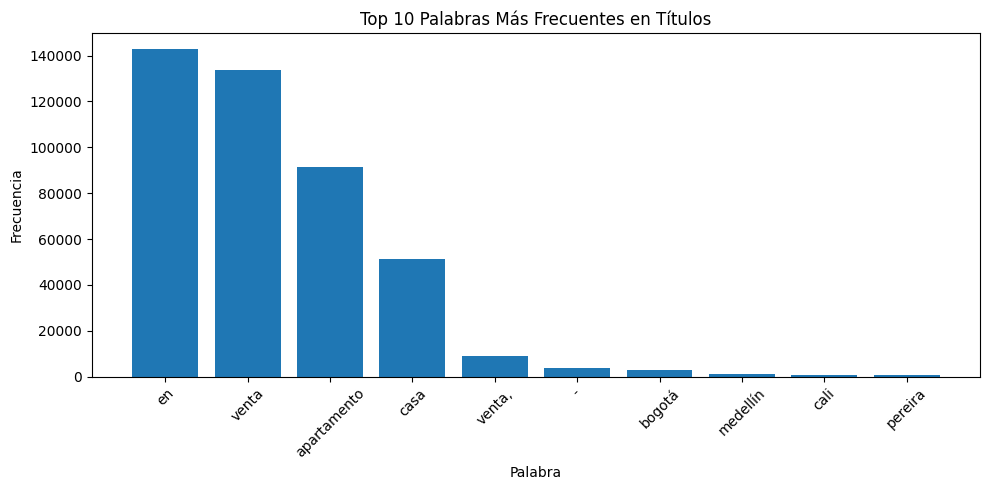

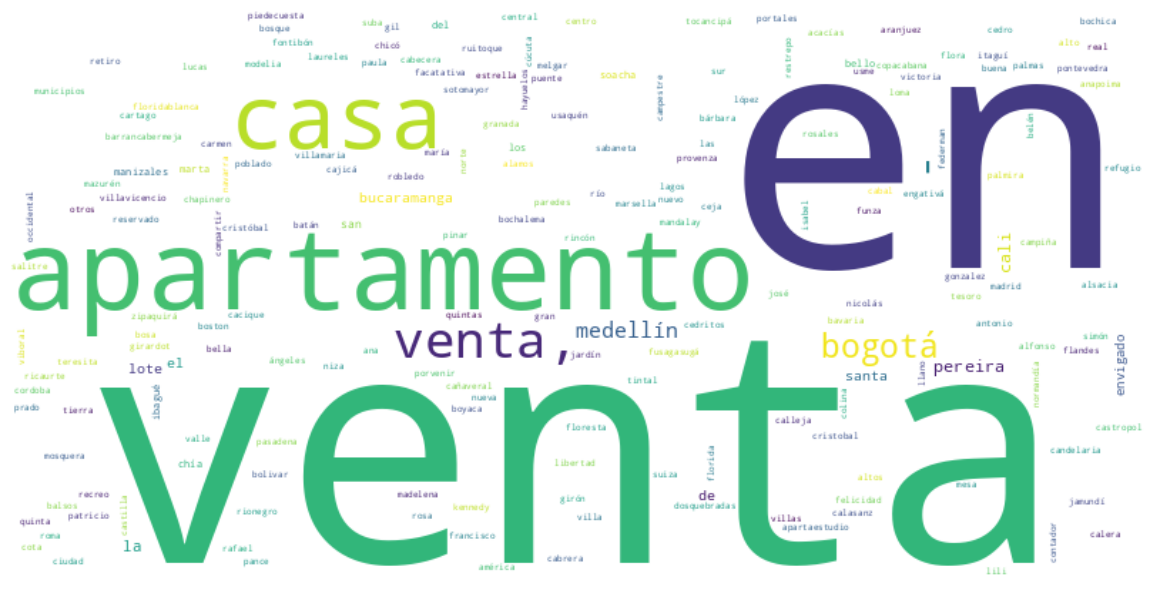

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Leer el resultado del conteo de palabras
df_wordcount = pd.read_csv("/content/result_wordcount.txt", sep="\t", names=["Palabra", "Frecuencia"])

# Crear gráfico de barras - Top 10 palabras
top10 = df_wordcount.sort_values("Frecuencia", ascending=False).head(10)
plt.figure(figsize=(10, 5))
plt.bar(top10["Palabra"], top10["Frecuencia"])
plt.title("Top 10 Palabras Más Frecuentes en Títulos")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/top10_palabras_barras.png")

# Crear nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(zip(df_wordcount["Palabra"], df_wordcount["Frecuencia"])))
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.savefig("/content/nube_palabras.png")

"/content/top10_palabras_barras.png", "/content/nube_palabras.png"